In [2]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_gridFit/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


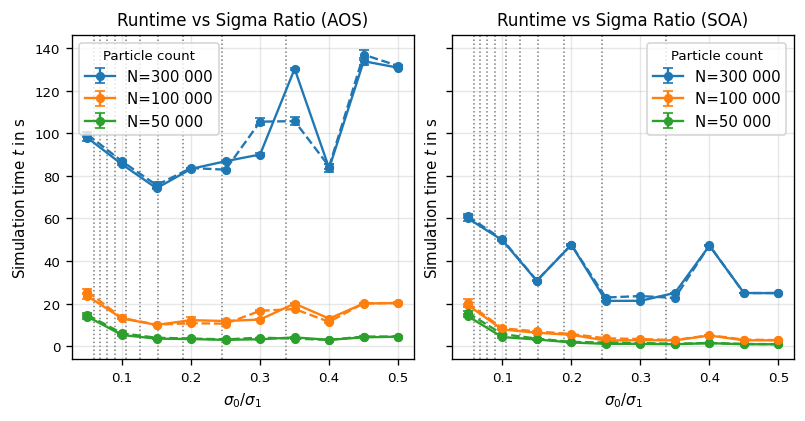

Plot mapping: solid line (-) = gridFitOn (fitOn), dashed line (--) = gridFitOff (fitOff).
Saved: ../thesis_plots/gridFit.pdf
Vertical markers at fitted-grid transition sigma ratios: [0.05925921296064804, 0.06767463373168658, 0.0777776388819441, 0.0901307565378269, 0.10556652832641633, 0.12539001950097503, 0.15185134256712837, 0.18888819440972046, 0.24444347217360868, 0.33703560178008896]


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml if not encoded in path."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def infer_grid_fit_mode(parts: tuple[str, ...]) -> str | None:
    """Infer whether a run belongs to gridFitOn or gridFitOff from path parts."""
    for token in parts:
        if token in {"gridFitOn", "gridFitOff"}:
            return token
    return None


def collect_runtime_data(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively."""
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        grid_fit = infer_grid_fit_mode(parts)
        if grid_fit is None:
            continue

        if not any(p.startswith("sigmaRatio_") for p in parts):
            continue
        if not any(p.startswith("dataLayout_") for p in parts):
            continue
        if not any(p.startswith("run_") for p in parts):
            continue

        sigma_ratio_str = next(p.split("_")[1] for p in parts if p.startswith("sigmaRatio_"))
        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        data_layout = next(p.split("_")[1] for p in parts if p.startswith("dataLayout_"))
        run = int(next(p.split("_")[1] for p in parts if p.startswith("run_")))

        total_dir = next((p for p in parts if p.startswith("totalParticles_")), None)
        if total_dir is not None:
            total_particles = int(total_dir.split("_")[1])
        else:
            total_particles = infer_total_particles_from_input(log_path.parent)
            if total_particles is None:
                continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "grid_fit": grid_fit,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "data_layout": data_layout,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex=False):
    """Style settings tuned for thesis figures included at ~\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "legend.title_fontsize": 8,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }
    )


def plot_runtime_vs_sigma(
    df: pd.DataFrame,
    data_layout: str,
    ax=None,
    error_mode: str = "t86",
    transition_sigmas: list[float] | None = None,
    legend_loc: str = "best",
):
    """Plot mean runtime vs sigma ratio for one data layout with error bars."""
    subset = df[df["data_layout"].str.lower() == data_layout.lower()].copy()
    subset = subset[~subset["sigma_ratio"].round(2).eq(0.55)].copy()
    subset = subset[subset["total_particles"] != 1000].copy()
    if subset.empty:
        raise ValueError(f"No rows found for data_layout={data_layout!r}.")

    summary = (
        subset.groupby(["grid_fit", "total_particles", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["grid_fit", "total_particles", "sigma_ratio"])
    )

    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    unique_particles = sorted(summary["total_particles"].unique(), reverse=True)
    colors = plt.cm.tab10(range(len(unique_particles)))
    particle_color_map = {p: colors[i] for i, p in enumerate(unique_particles)}

    line_styles = {"gridFitOn": "-", "gridFitOff": "--"}
    mode_order = ["gridFitOn", "gridFitOff"]
    labeled_particles = set()
    for mode in mode_order:
        mode_subset = summary[summary["grid_fit"] == mode]
        for total_particles, grp in mode_subset.groupby("total_particles"):
            color = particle_color_map[total_particles]
            label = f"N={total_particles:,}".replace(",", " ") if total_particles not in labeled_particles else "_nolegend_"
            labeled_particles.add(total_particles)
            ax.errorbar(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                yerr=grp["error"],
                marker="o",
                linestyle=line_styles.get(mode, "-"),
                capsize=3,
                color=color,
                label=label,
            )

    for sigma in (transition_sigmas or []):
        ax.axvline(x=sigma, color="0.35", linestyle=":", linewidth=0.9, alpha=0.8, zorder=0)

    ax.set_title(f"Runtime vs Sigma Ratio ({data_layout.upper()})")
    ax.set_xlabel(r"$\sigma_0 / \sigma_1$")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(
        range(len(labels)),
        key=lambda i: int(labels[i].split("=")[1].replace(" ", "")) if labels[i].startswith("N=") else -1,
        reverse=True,
    )
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Particle count",
        fontsize=9,
        loc=legend_loc,
    )


def fitted_grid_transition_sigmas_from_last_cell(max_ratio: int = 13, dense_points: int = 20000) -> list[float]:
    """Read all fitted-grid transition positions in the plotted sigma range (fitted only)."""
    analysis_df = globals().get("df")
    if analysis_df is None:
        return []

    required = {"sigma_ratio", "num_levels", "higher_over_lower_true_x"}
    if not required.issubset(set(analysis_df.columns)):
        return []

    runtime = globals().get("runtime_df")
    if runtime is not None and not runtime.empty and "sigma_ratio" in runtime.columns:
        sigma_min = float(runtime["sigma_ratio"].min())
        sigma_max = float(runtime["sigma_ratio"].max())
    else:
        sigma_min = float(analysis_df["sigma_ratio"].min())
        sigma_max = float(analysis_df["sigma_ratio"].max())

    if "hgmatching_cell_sizes_both_modes" in globals():
        dense_sigmas = np.linspace(sigma_min, sigma_max, dense_points)
        dense_res = hgmatching_cell_sizes_both_modes(dense_sigmas)
        fitted = pd.DataFrame(
            {
                "sigma_ratio": [r["sigma_ratio"] for r in dense_res],
                "num_levels": [r["num_levels"] for r in dense_res],
                "ratio_true": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in dense_res],
            }
        )
    else:
        fitted = analysis_df.rename(columns={"higher_over_lower_true_x": "ratio_true"})[["sigma_ratio", "num_levels", "ratio_true"]].copy()

    fitted = fitted.loc[fitted["num_levels"] >= 2].copy()
    if fitted.empty:
        return []

    fitted = fitted.sort_values("sigma_ratio").drop_duplicates(subset=["sigma_ratio"], keep="last")
    sigmas = fitted["sigma_ratio"].astype(float).to_numpy()
    ratios = fitted["ratio_true"].astype(float).to_numpy()

    transitions = []
    for i in range(len(sigmas) - 1):
        if abs(ratios[i + 1] - ratios[i]) > 1e-12 and ratios[i] <= max_ratio:
            transitions.append(float(0.5 * (sigmas[i] + sigmas[i + 1])))

    return transitions


# Collect data and generate one export-ready figure
runtime_df = collect_runtime_data(".")
runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()
transition_sigmas = fitted_grid_transition_sigmas_from_last_cell()

# If your LaTeX setup has full TeX support for Matplotlib, set this to True.
apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.4), sharey=True, constrained_layout=True)
    plot_runtime_vs_sigma(runtime_df, "AoS", ax=axes[0], error_mode="t86", transition_sigmas=transition_sigmas, legend_loc="upper left")
    plot_runtime_vs_sigma(runtime_df, "SoA", ax=axes[1], error_mode="t86", transition_sigmas=transition_sigmas)

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    pdf_path = output_dir / "gridFit.pdf"

    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    print("Plot mapping: solid line (-) = gridFitOn (fitOn), dashed line (--) = gridFitOff (fitOff).")
    print(f"Saved: {pdf_path}")
    if transition_sigmas:
        print(f"Vertical markers at fitted-grid transition sigma ratios: {transition_sigmas}")
    else:
        print("No vertical markers: run Cell 3 first to populate fitted-grid transition data.")

In [10]:
import math
import numpy as np
import pandas as pd


def _cellblock3d_cell_length(box_min, box_max, interaction_length, cell_size_factor=1.0):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellSizeFactor."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min

    # CellBlock3D behavior for csf >= 1.0 / < 1.0 only affects halo width, not owned cell length.
    cells_per_dim = np.maximum(np.floor(box_lengths / (interaction_length * cell_size_factor)).astype(int), 1)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def _cellblock3d_cell_length_from_cells_per_dim(box_min, box_max, cells_per_dim):
    """Mirror CellBlock3D::rebuild for the constructor that takes cellsPerDimension."""
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)
    box_lengths = box_max - box_min
    cells_per_dim = np.asarray(cells_per_dim, dtype=int)
    cell_length = box_lengths / cells_per_dim
    return cell_length, cells_per_dim


def hgmatching_cell_sizes_both_modes(
    sigma_ratios,
    box_min=(0.0, 0.0, 0.0),
    box_max=(20.0, 20.0, 20.0),
    skin=0.1,
    higher_cutoff=1.5,
    cell_size_factor=1.0,
    sigma_max=0.5,
    cutoff_scale=3.0,
    use_generator_rounding=True,
):
    """
    Mimic HierarchicalGridMatching + LinkedCells + CellBlock3D for both fittedGrids=false and fittedGrids=true.

    Returns per sigma ratio:
    - higher cell length
    - lower cell length for fittedGrids=false (ratio-based csf)
    - lower cell length for fittedGrids=true (cellsPerDimension path)
    - lowerCellsPerHigher check values
    """
    box_min = np.asarray(box_min, dtype=float)
    box_max = np.asarray(box_max, dtype=float)

    max_length = float(np.min(box_max - box_min) - skin)
    out = []

    for sigma_ratio in sigma_ratios:
        sigma0 = sigma_max * float(sigma_ratio)
        cutoff0 = cutoff_scale * sigma0
        if use_generator_rounding:
            # input_generator writes cutoff0 with 6 decimals.
            cutoff0 = float(f"{cutoff0:.6f}")

        # Mimic constructor preprocessing: clamp > maxLength, sort, unique.
        cutoffs = sorted({min(cutoff0, max_length), min(higher_cutoff, max_length)})

        # Highest level (always constructed first with cellSizeFactor).
        highest_interaction = cutoffs[-1] + skin
        higher_cell_length, higher_cells_per_dim = _cellblock3d_cell_length(
            box_min, box_max, highest_interaction, cell_size_factor
        )

        # If lower cutoff collapsed away through uniqueness, only one level exists.
        if len(cutoffs) < 2:
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": np.array([np.nan, np.nan, np.nan]),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        lower_interaction = cutoffs[0] + skin

        # Pre-check in HierarchicalGridMatching before branch on fittedGrids.
        lower_cells_per_higher = np.floor(higher_cell_length / (lower_interaction * cell_size_factor)).astype(int)
        if np.any(lower_cells_per_higher < 2):
            # Level removed, hierarchy degenerates to highest level only.
            out.append(
                {
                    "sigma_ratio": float(sigma_ratio),
                    "num_levels": 1,
                    "lower_cells_per_higher": lower_cells_per_higher.copy(),
                    "higher_cell_length": higher_cell_length.copy(),
                    "lower_cell_length_false": higher_cell_length.copy(),
                    "lower_cell_length_true": higher_cell_length.copy(),
                }
            )
            continue

        # fittedGrids == false branch: ratio-based cellSizeFactor for lower level.
        ratio = lower_interaction / highest_interaction
        lower_csf = cell_size_factor * ratio
        lower_cell_length_false, _ = _cellblock3d_cell_length(box_min, box_max, highest_interaction, lower_csf)

        # fittedGrids == true branch: explicitly matched cellsPerDimension.
        lower_cells_per_dim_true = lower_cells_per_higher * higher_cells_per_dim
        lower_cell_length_true, _ = _cellblock3d_cell_length_from_cells_per_dim(
            box_min, box_max, lower_cells_per_dim_true
        )

        out.append(
            {
                "sigma_ratio": float(sigma_ratio),
                "num_levels": 2,
                "lower_cells_per_higher": lower_cells_per_higher.copy(),
                "higher_cell_length": higher_cell_length.copy(),
                "lower_cell_length_false": lower_cell_length_false.copy(),
                "lower_cell_length_true": lower_cell_length_true.copy(),
            }
        )

    return out


# Example on your current gridFit sigma ratios.
#sigmas = np.linspace(0.24, 0.50, 10)
sigmas = [0.05,0.24, 0.268889, 0.297778, 0.326667, 0.355556, 0.384444, 0.413333, 0.442222, 0.471111, 0.5]
sigmas=np.linspace(0.1,0.4,4)
sigmas=np.append(sigmas, [0.48])
res = hgmatching_cell_sizes_both_modes(sigmas)

df = pd.DataFrame(
    {
        "sigma_ratio": [r["sigma_ratio"] for r in res],
        "num_levels": [r["num_levels"] for r in res],
        "lower_cells_per_higher_x": [
            (int(r["lower_cells_per_higher"][0]) if not np.isnan(r["lower_cells_per_higher"][0]) else np.nan)
            for r in res
        ],
        "higher_cell_length_x": [r["higher_cell_length"][0] for r in res],
        "higher_over_lower_false_x": [r["higher_cell_length"][0] / r["lower_cell_length_false"][0] for r in res],
        "higher_over_lower_true_x": [r["higher_cell_length"][0] / r["lower_cell_length_true"][0] for r in res],
    }
)

df

,sigma_ratio,num_levels,lower_cells_per_higher_x,higher_cell_length_x,higher_over_lower_false_x,higher_over_lower_true_x
0,0.10,2,6,1.666667,6.666667,6.0
1,0.20,2,4,1.666667,4.166667,4.0
2,0.30,2,3,1.666667,3.000000,3.0
3,0.40,2,2,1.666667,2.333333,2.0
4,0.48,2,2,1.666667,2.000000,2.0
